**Step 1**

In [3]:
import numpy as np

np.random.seed(42)  # for reproducibility

# -------------------------------
# (a) Create 6x4 matrix
# -------------------------------
scores = np.random.randint(0, 101, (6, 4))
print("Original Scores:\n", scores)

# -------------------------------
# (b) Normalize using broadcasting
# -------------------------------
mins = scores.min(axis=0)
maxs = scores.max(axis=0)

normalized = (scores - mins) / (maxs - mins)
print("\nNormalized Scores:\n", normalized)

# -------------------------------
# (c) Boolean mask (avg >= 60)
# -------------------------------
avg_scores = scores.mean(axis=1)
mask = avg_scores >= 60

passing_students = scores[mask]

print("\nAverage Scores:\n", avg_scores)
print("\nPassing Mask:\n", mask)
print("\nPassing Students:\n", passing_students)

# -------------------------------
# (d) Replace scores < 40 with column mean
# -------------------------------
col_mean = scores.mean(axis=0)

cleaned_scores = np.where(scores < 40, col_mean, scores)

print("\nColumn Means:\n", col_mean)
print("\nCleaned Scores (values < 40 replaced):\n", cleaned_scores)

# -------------------------------
# (e) Dot product (weighted scoring)
# -------------------------------
weights = np.random.rand(4)

weighted_scores = normalized @ weights

print("\nWeights:\n", weights)
print("\nWeighted Scores:\n", weighted_scores)

Original Scores:
 [[51 92 14 71]
 [60 20 82 86]
 [74 74 87 99]
 [23  2 21 52]
 [ 1 87 29 37]
 [ 1 63 59 20]]

Normalized Scores:
 [[0.68493151 1.         0.         0.64556962]
 [0.80821918 0.2        0.93150685 0.83544304]
 [1.         0.8        1.         1.        ]
 [0.30136986 0.         0.09589041 0.40506329]
 [0.         0.94444444 0.20547945 0.21518987]
 [0.         0.67777778 0.61643836 0.        ]]

Average Scores:
 [57.   62.   83.5  24.5  38.5  35.75]

Passing Mask:
 [False  True  True False False False]

Passing Students:
 [[60 20 82 86]
 [74 74 87 99]]

Column Means:
 [35.         56.33333333 48.66666667 60.83333333]

Cleaned Scores (values < 40 replaced):
 [[51.         92.         48.66666667 71.        ]
 [60.         56.33333333 82.         86.        ]
 [74.         74.         87.         99.        ]
 [35.         56.33333333 48.66666667 52.        ]
 [35.         87.         48.66666667 60.83333333]
 [35.         63.         59.         60.83333333]]

Weights:
 [

**Step 2**

In [4]:
import pandas as pd

# -------------------------------
# Load dataset
# -------------------------------
df = pd.read_csv('train.csv')

# -------------------------------
# Basic Views
# -------------------------------
print("HEAD (10 rows):\n", df.head(10))
print("\nTAIL (5 rows):\n", df.tail(5))
print("\nSAMPLE (8 rows):\n", df.sample(8, random_state=42))

# -------------------------------
# Structure Info
# -------------------------------
print("\nSHAPE:", df.shape)

print("\nINFO:")
df.info()

print("\nDATA TYPES:\n", df.dtypes)

print("\nCOLUMNS:\n", df.columns.tolist())

# -------------------------------
# Column Type Analysis
# -------------------------------
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("\nNumber of Numerical Columns:", len(num_cols))
print("Numerical Columns:", list(num_cols))

print("\nNumber of Categorical Columns:", len(cat_cols))
print("Categorical Columns:", list(cat_cols))

# -------------------------------
# Missing Values Analysis
# -------------------------------
missing_per_col = df.isnull().sum()
total_missing = df.isnull().sum().sum()

cols_with_missing = (missing_per_col > 0).sum()

print("\nMissing Values per Column:\n", missing_per_col)
print("\nColumns with Missing Values:", cols_with_missing)
print("Total Missing Cells:", total_missing)

HEAD (10 rows):
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timo

**Step 3**

In [5]:
# -------------------------------
# Missing % Calculation
# -------------------------------
missing_percent = (df.isnull().sum() / len(df)) * 100

print("Missing Percentage per Column:\n", missing_percent.sort_values(ascending=False))

Missing Percentage per Column:
 Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64


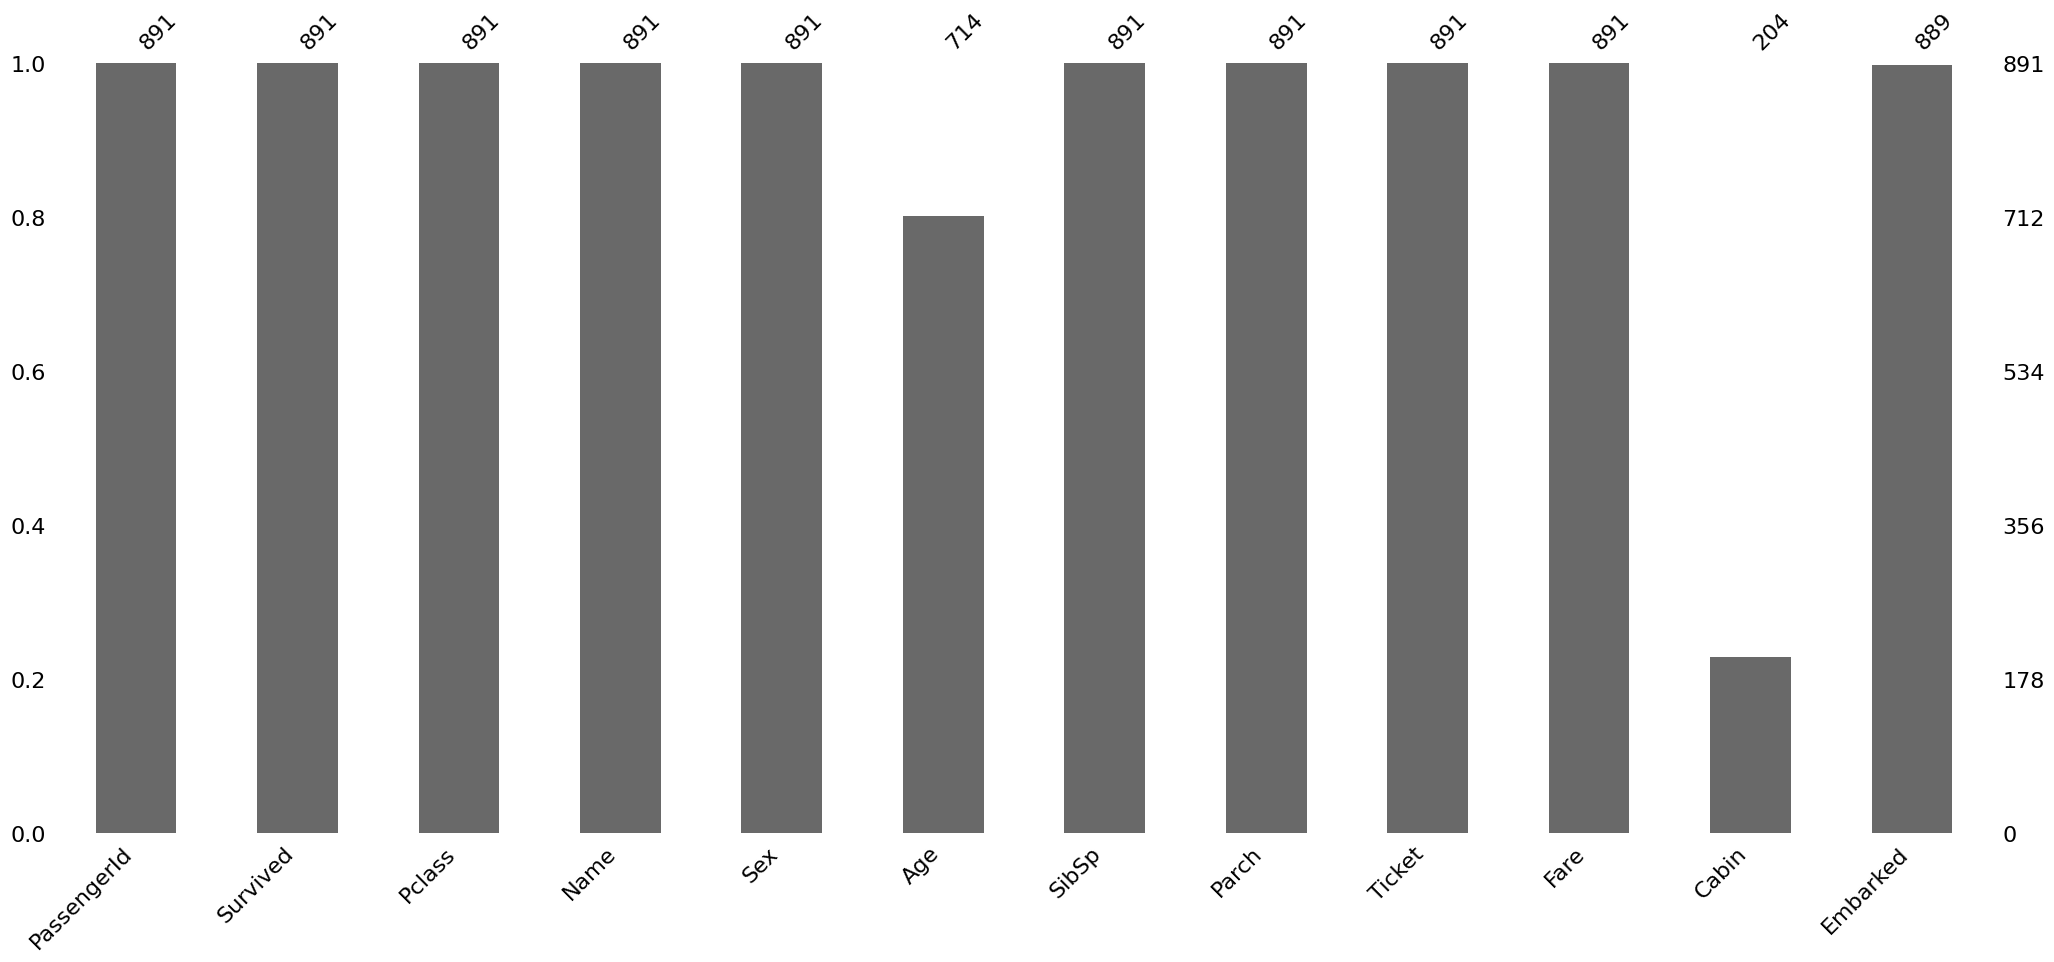

In [6]:
import missingno as msno
import matplotlib.pyplot as plt

msno.bar(df)
plt.show()

**Step 4**

In [7]:
import pandas as pd

# -------------------------------
# Save original dtypes (BEFORE)
# -------------------------------
before_dtypes = df.dtypes

# -------------------------------
# Make a copy
# -------------------------------
df_clean = df.copy()

# -------------------------------
# 1. Create has_cabin feature
# -------------------------------
df_clean['has_cabin'] = df_clean['Cabin'].notnull().astype(int)

# -------------------------------
# 2. Drop columns
# -------------------------------
df_clean = df_clean.drop(columns=['Cabin', 'PassengerId', 'Ticket'])

# -------------------------------
# 3. Handle missing values
# -------------------------------

# Age → group-based median (IMPORTANT FIX)
df_clean['Age'] = df_clean.groupby(['Pclass','Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

# Embarked → mode
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# -------------------------------
# 4. Standardize text
# -------------------------------
df_clean['Sex'] = df_clean['Sex'].str.lower().str.strip()
df_clean['Embarked'] = df_clean['Embarked'].str.upper().str.strip()

# -------------------------------
# 5. Convert to categorical
# -------------------------------
df_clean['Survived'] = df_clean['Survived'].astype('category')
df_clean['Pclass'] = df_clean['Pclass'].astype('category')
df_clean['Sex'] = df_clean['Sex'].astype('category')
df_clean['Embarked'] = df_clean['Embarked'].astype('category')

# -------------------------------
# 6. Remove duplicates
# -------------------------------
df_clean = df_clean.drop_duplicates()

# -------------------------------
# 7. Verify no missing values
# -------------------------------
print("Total Missing Values:", df_clean.isnull().sum().sum())

# -------------------------------
# 8. Strategy Summary (REQUIRED)
# -------------------------------
print("\nData Cleaning Strategy:")
print("Age → Filled using median grouped by Pclass and Sex")
print("Embarked → Filled using mode")
print("Cabin → Converted to 'has_cabin' binary feature and original column dropped")

# -------------------------------
# 9. Dtype Comparison Table
# -------------------------------
after_dtypes = df_clean.dtypes

dtype_comparison = pd.concat([before_dtypes, after_dtypes], axis=1)
dtype_comparison.columns = ['Before', 'After']

print("\nDtype Comparison:\n")
print(dtype_comparison)

# -------------------------------
# Final dataset info
# -------------------------------
print("\nFINAL CLEANED DATA INFO:\n")
df_clean.info()

Total Missing Values: 0

Data Cleaning Strategy:
Age → Filled using median grouped by Pclass and Sex
Embarked → Filled using mode
Cabin → Converted to 'has_cabin' binary feature and original column dropped

Dtype Comparison:

              Before     After
PassengerId    int64       NaN
Survived       int64  category
Pclass         int64  category
Name          object    object
Sex           object  category
Age          float64   float64
SibSp          int64     int64
Parch          int64     int64
Ticket        object       NaN
Fare         float64   float64
Cabin         object       NaN
Embarked      object  category
has_cabin        NaN     int64

FINAL CLEANED DATA INFO:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Survived   891 non-null    category
 1   Pclass     891 non-null    category
 2   Name       891 non-null    object  
 3 

**Step 5**

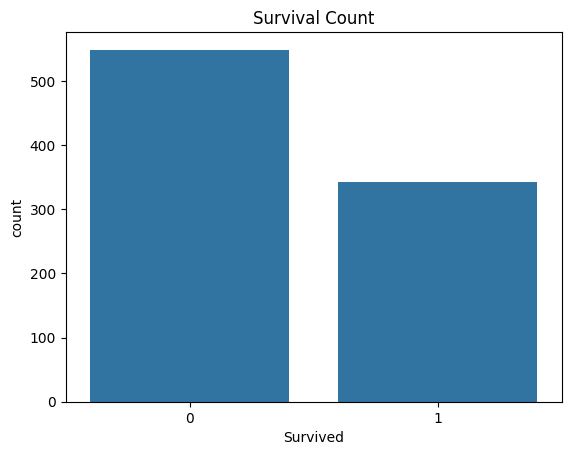

Survival Counts:
 Survived
0    549
1    342
Name: count, dtype: int64

Survival Rate (%):
 Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df_clean, x='Survived')
plt.title("Survival Count")
plt.show()

print("Survival Counts:\n", df_clean['Survived'].value_counts())
print("\nSurvival Rate (%):\n", df_clean['Survived'].value_counts(normalize=True) * 100)

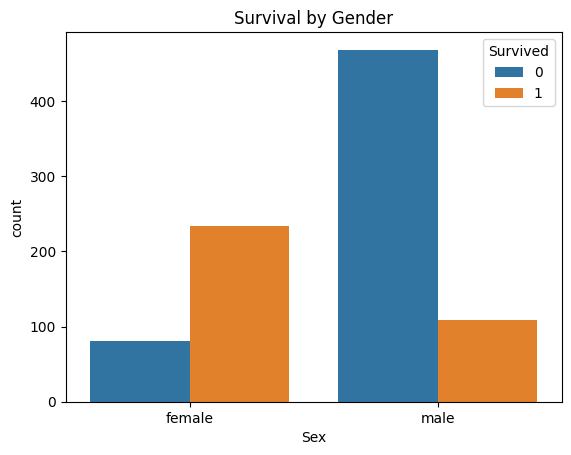

Survived          0          1
Sex                           
female    25.796178  74.203822
male      81.109185  18.890815


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df_clean, x='Sex', hue='Survived')
plt.title("Survival by Gender")
plt.show()

print(pd.crosstab(df_clean['Sex'], df_clean['Survived'], normalize='index') * 100)

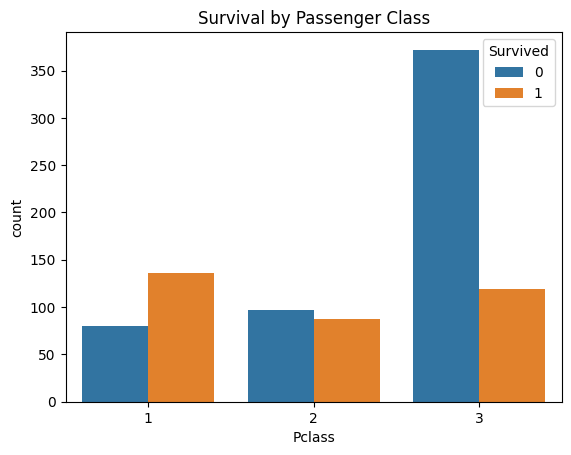

Survived          0          1
Pclass                        
1         37.037037  62.962963
2         52.717391  47.282609
3         75.763747  24.236253


In [10]:
sns.countplot(data=df_clean, x='Pclass', hue='Survived')
plt.title("Survival by Passenger Class")
plt.show()

print(pd.crosstab(df_clean['Pclass'], df_clean['Survived'], normalize='index') * 100)

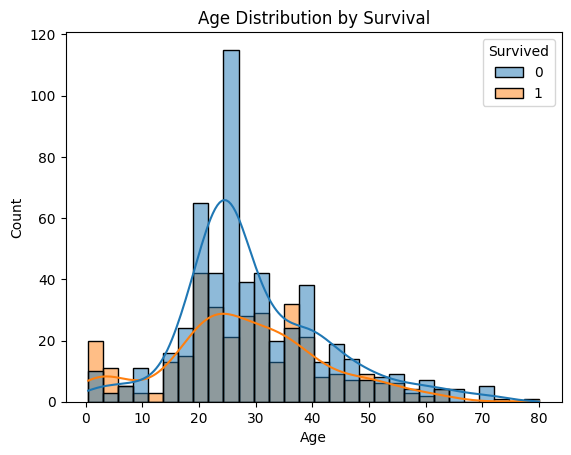

In [11]:
sns.histplot(data=df_clean, x='Age', hue='Survived', bins=30, kde=True)
plt.title("Age Distribution by Survival")
plt.show()

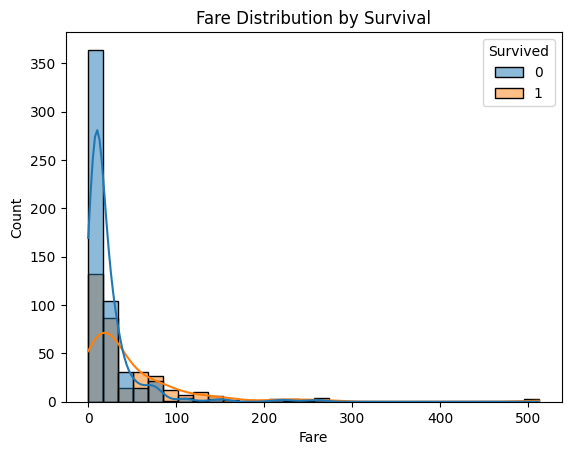

In [12]:
sns.histplot(data=df_clean, x='Fare', hue='Survived', bins=30, kde=True)
plt.title("Fare Distribution by Survival")
plt.show()

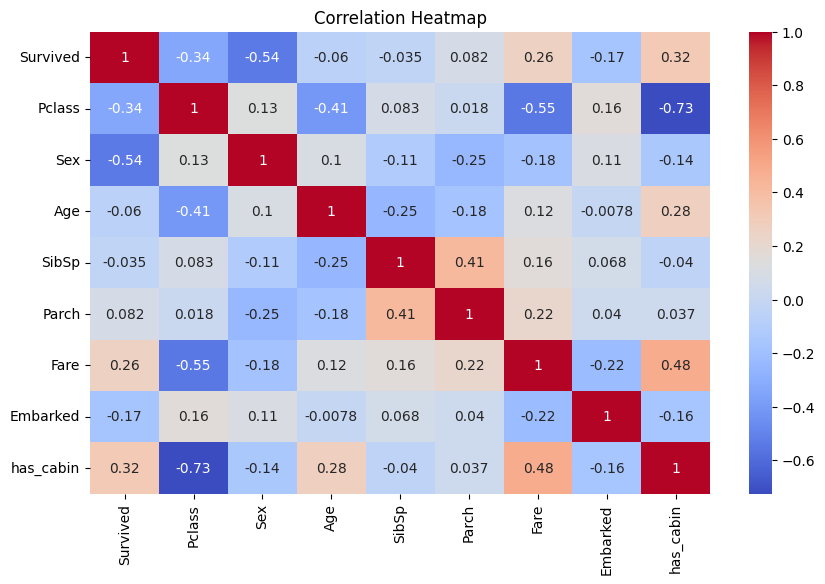

In [13]:
df_corr = df_clean.copy()

# Convert categorical → numeric
df_corr['Sex'] = df_corr['Sex'].cat.codes
df_corr['Embarked'] = df_corr['Embarked'].cat.codes
df_corr['Pclass'] = df_corr['Pclass'].cat.codes
df_corr['Survived'] = df_corr['Survived'].cat.codes  # 🔥 IMPORTANT

# Drop only non-useful text column
df_corr = df_corr.drop(columns=['Name'])

# Now correlation
plt.figure(figsize=(10,6))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Step 6**

In [15]:
# -------------------------------
# IQR for Fare
# -------------------------------
Q1_fare = df_clean['Fare'].quantile(0.25)
Q3_fare = df_clean['Fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare

lower_fare = Q1_fare - 1.5 * IQR_fare
upper_fare = Q3_fare + 1.5 * IQR_fare

# -------------------------------
# IQR for Age
# -------------------------------
Q1_age = df_clean['Age'].quantile(0.25)
Q3_age = df_clean['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age

lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

print("Fare IQR:", IQR_fare)
print("Fare Bounds:", lower_fare, upper_fare)

print("\nAge IQR:", IQR_age)
print("Age Bounds:", lower_age, upper_age)

Fare IQR: 23.0896
Fare Bounds: -26.724 65.6344

Age IQR: 14.5
Age Bounds: -0.25 57.75


In [16]:
# Count Fare outliers
fare_outliers = df_clean[(df_clean['Fare'] < lower_fare) | (df_clean['Fare'] > upper_fare)]
print("Number of Fare outliers:", len(fare_outliers))

# Count Age outliers
age_outliers = df_clean[(df_clean['Age'] < lower_age) | (df_clean['Age'] > upper_age)]
print("Number of Age outliers:", len(age_outliers))

Number of Fare outliers: 116
Number of Age outliers: 33


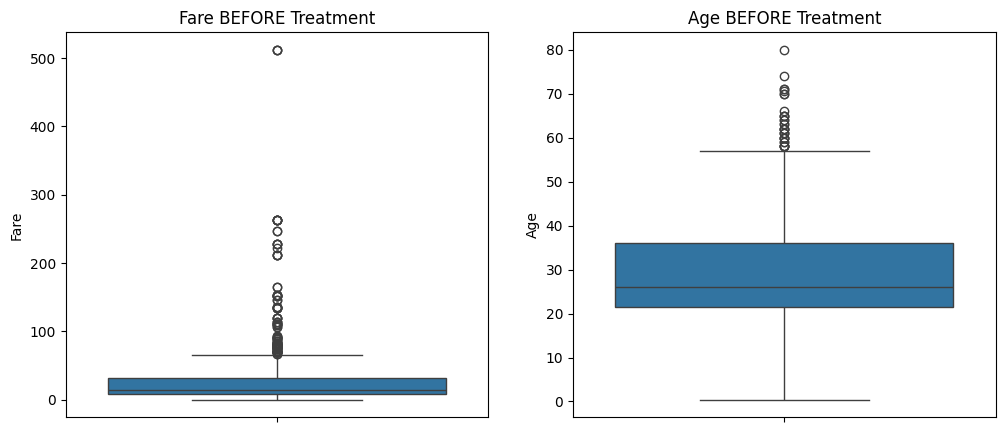

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df_clean['Fare'])
plt.title("Fare BEFORE Treatment")

plt.subplot(1,2,2)
sns.boxplot(y=df_clean['Age'])
plt.title("Age BEFORE Treatment")

plt.show()

In [18]:
# Cap Fare at 99th percentile
fare_cap = df_clean['Fare'].quantile(0.99)

df_clean['Fare'] = df_clean['Fare'].clip(upper=fare_cap)

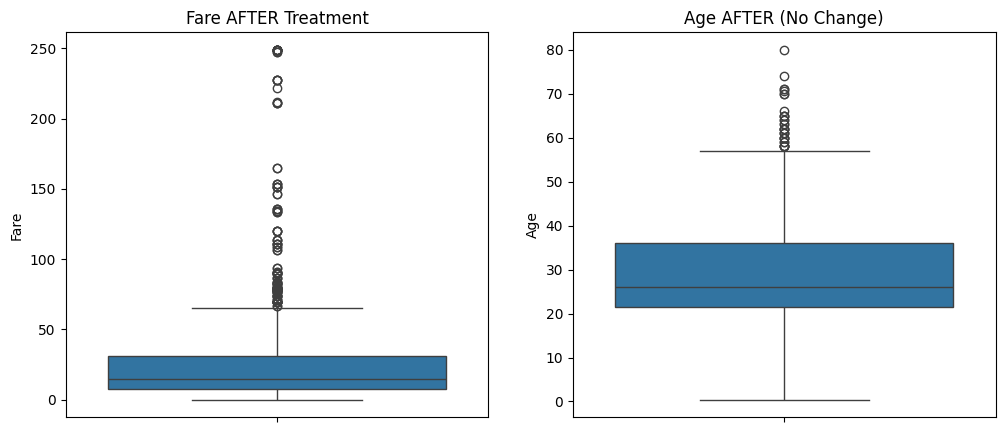

In [19]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df_clean['Fare'])
plt.title("Fare AFTER Treatment")

plt.subplot(1,2,2)
sns.boxplot(y=df_clean['Age'])
plt.title("Age AFTER (No Change)")

plt.show()

**Step 7**

In [20]:
# -------------------------------
# 1. family_size
# -------------------------------
df_clean['family_size'] = df_clean['SibSp'] + df_clean['Parch'] + 1

# -------------------------------
# 2. is_alone
# -------------------------------
df_clean['is_alone'] = (df_clean['family_size'] == 1).astype(int)

# -------------------------------
# 3. fare_per_person
# -------------------------------
df_clean['fare_per_person'] = df_clean['Fare'] / df_clean['family_size']

# -------------------------------
# 4. title extraction
# -------------------------------
df_clean['title'] = df['Name'].str.extract(r',\s*([^\.]+)\.')

# Group rare titles
common_titles = ['Mr', 'Miss', 'Mrs', 'Master']
df_clean['title'] = df_clean['title'].apply(lambda x: x if x in common_titles else 'Rare')

# -------------------------------
# 5. age_group
# -------------------------------
def age_category(age):
    if age < 12:
        return 'Child'
    elif age < 18:
        return 'Teen'
    elif age < 60:
        return 'Adult'
    else:
        return 'Senior'

df_clean['age_group'] = df_clean['Age'].apply(age_category)

# -------------------------------
# 6. deck (from original Cabin)
# -------------------------------
df_clean['deck'] = df['Cabin'].str[0]
df_clean['deck'] = df_clean['deck'].fillna('Unknown')

# -------------------------------
# 7. fare_bin
# -------------------------------
df_clean['fare_bin'] = pd.qcut(df_clean['Fare'], q=4, labels=['Low','Medium','High','VHigh'])

# -------------------------------
# Value counts (IMPORTANT)
# -------------------------------
print("Title:\n", df_clean['title'].value_counts())
print("\nAge Group:\n", df_clean['age_group'].value_counts())
print("\nDeck:\n", df_clean['deck'].value_counts())
print("\nFare Bin:\n", df_clean['fare_bin'].value_counts())

# -------------------------------
# Show first 10 rows
# -------------------------------
print(df_clean[['family_size','is_alone','fare_per_person','title','age_group','deck','fare_bin']].head(10))

Title:
 title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

Age Group:
 age_group
Adult     752
Child      68
Teen       45
Senior     26
Name: count, dtype: int64

Deck:
 deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

Fare Bin:
 fare_bin
Medium    224
Low       223
High      222
VHigh     222
Name: count, dtype: int64
   family_size  is_alone  fare_per_person   title age_group     deck fare_bin
0            2         0          3.62500      Mr     Adult  Unknown      Low
1            2         0         35.64165     Mrs     Adult        C    VHigh
2            1         1          7.92500    Miss     Adult  Unknown   Medium
3            2         0         26.55000     Mrs     Adult        C    VHigh
4            1         1          8.05000      Mr     Adult  Unknown   Medium
5            1         1          8.4583

**Step 8**

In [22]:
# -------------------------------
# (a) Sex → Label Encoding
# -------------------------------
df_clean['sex_encoded'] = df_clean['Sex'].map({'male': 0, 'female': 1})

# -------------------------------
# (b) Embarked → One-Hot (FIXED)
# -------------------------------
embarked_dummies = pd.get_dummies(df_clean['Embarked'], prefix='Embarked', drop_first=True)
df_clean = pd.concat([df_clean, embarked_dummies], axis=1)

# -------------------------------
# (c) Title → One-Hot (correct)
# -------------------------------
title_dummies = pd.get_dummies(df_clean['title'], prefix='title', drop_first=True)
df_clean = pd.concat([df_clean, title_dummies], axis=1)

# -------------------------------
# (d) Ordinal Encoding
# -------------------------------
age_map = {'Child':0, 'Teen':1, 'Adult':2, 'Senior':3}
fare_map = {'Low':0, 'Medium':1, 'High':2, 'VHigh':3}

df_clean['age_group_encoded'] = df_clean['age_group'].map(age_map)
df_clean['fare_bin_encoded'] = df_clean['fare_bin'].map(fare_map)

# -------------------------------
# DROP NON-ML COLUMNS (IMPORTANT)
# -------------------------------
df_clean = df_clean.drop(columns=[
    'Name', 'Sex', 'Embarked', 'title', 'age_group', 'fare_bin'
])

# -------------------------------
# Final shape
# -------------------------------
print("Final Shape After Encoding:", df_clean.shape)

# -------------------------------
# ML Features list
# -------------------------------
feature_cols = [col for col in df_clean.columns if col != 'Survived']

print("\nML Feature Columns:\n", feature_cols)

Final Shape After Encoding: (891, 27)

ML Feature Columns:
 ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'has_cabin', 'family_size', 'is_alone', 'fare_per_person', 'deck', 'sex_encoded', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'title_Miss', 'title_Mr', 'title_Mrs', 'title_Rare', 'age_group_encoded', 'fare_bin_encoded', 'Embarked_Q', 'Embarked_S', 'title_Miss', 'title_Mr', 'title_Mrs', 'title_Rare']


In [23]:
# -------------------------------
# Remove duplicate columns
# -------------------------------
df_clean = df_clean.loc[:, ~df_clean.columns.duplicated()]

# -------------------------------
# Drop non-encoded categorical column
# -------------------------------
df_clean = df_clean.drop(columns=['deck'])

# -------------------------------
# Final shape
# -------------------------------
print("Final Shape After Cleaning:", df_clean.shape)

# -------------------------------
# Final ML feature list
# -------------------------------
feature_cols = [col for col in df_clean.columns if col != 'Survived']

print("\nML Feature Columns:\n", feature_cols)

Final Shape After Cleaning: (891, 20)

ML Feature Columns:
 ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'has_cabin', 'family_size', 'is_alone', 'fare_per_person', 'sex_encoded', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'title_Miss', 'title_Mr', 'title_Mrs', 'title_Rare', 'age_group_encoded', 'fare_bin_encoded']


**Step 9**

In [24]:
from sklearn.preprocessing import StandardScaler

# -------------------------------
# Columns to scale
# -------------------------------
scale_cols = ['Age', 'Fare', 'fare_per_person', 'family_size']

# -------------------------------
# BEFORE scaling
# -------------------------------
print("Before Scaling:\n")
for col in scale_cols:
    print(f"{col} → Mean: {df_clean[col].mean():.2f}, Std: {df_clean[col].std():.2f}")

# -------------------------------
# Apply scaling
# -------------------------------
scaler = StandardScaler()
df_clean[scale_cols] = scaler.fit_transform(df_clean[scale_cols])

# -------------------------------
# AFTER scaling
# -------------------------------
print("\nAfter Scaling:\n")
for col in scale_cols:
    print(f"{col} → Mean: {df_clean[col].mean():.2f}, Std: {df_clean[col].std():.2f}")

# -------------------------------
# Create final ML dataset
# -------------------------------
final_df = df_clean.copy()

# -------------------------------
# Final checks
# -------------------------------
print("\nFinal Dataset Info:\n")
final_df.info()

print("\nFirst 5 rows:\n")
print(final_df.head())

# -------------------------------
# Save dataset
# -------------------------------
final_df.to_csv("titanic_cleaned.csv", index=False)

Before Scaling:

Age → Mean: 29.11, Std: 13.30
Fare → Mean: 31.22, Std: 42.52
fare_per_person → Mean: 19.16, Std: 28.39
family_size → Mean: 1.90, Std: 1.61

After Scaling:

Age → Mean: 0.00, Std: 1.00
Fare → Mean: -0.00, Std: 1.00
fare_per_person → Mean: 0.00, Std: 1.00
family_size → Mean: -0.00, Std: 1.00

Final Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Survived           891 non-null    category
 1   Pclass             891 non-null    category
 2   Age                891 non-null    float64 
 3   SibSp              891 non-null    int64   
 4   Parch              891 non-null    int64   
 5   Fare               891 non-null    float64 
 6   has_cabin          891 non-null    int64   
 7   family_size        891 non-null    float64 
 8   is_alone           891 non-null    int64   
 9   fare_per_person    89

In [25]:
final_df = final_df.copy()

final_df['Survived'] = final_df['Survived'].astype(int)
final_df['Pclass'] = final_df['Pclass'].astype(int)
final_df['sex_encoded'] = final_df['sex_encoded'].astype(int)
final_df['fare_bin_encoded'] = final_df['fare_bin_encoded'].astype(int)

**Step 10**

In [27]:
# Convert to numeric for aggregation
df_clean['Survived'] = df_clean['Survived'].astype(int)
df_clean['Pclass'] = df_clean['Pclass'].astype(int)
df_clean['sex_encoded'] = df_clean['sex_encoded'].astype(int)

In [28]:
# Survival by Pclass
print(df_clean.groupby('Pclass')['Survived'].mean().round(3))

# Survival by Sex
print(df_clean.groupby('sex_encoded')['Survived'].mean().round(3))

# Combined
print(df_clean.groupby(['Pclass','sex_encoded'])['Survived'].mean().unstack().round(3))

Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64
sex_encoded
0    0.189
1    0.742
Name: Survived, dtype: float64
sex_encoded      0      1
Pclass                   
1            0.369  0.968
2            0.157  0.921
3            0.135  0.500


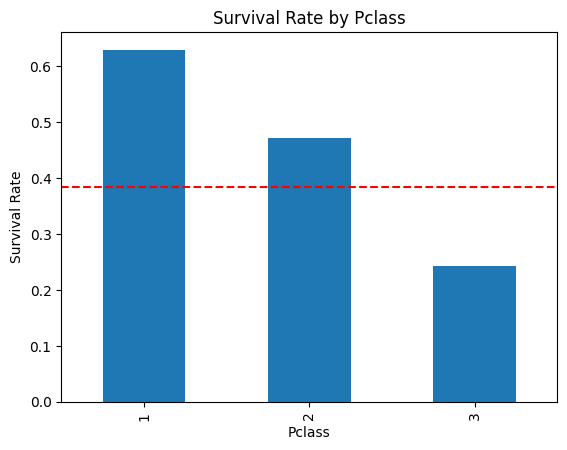

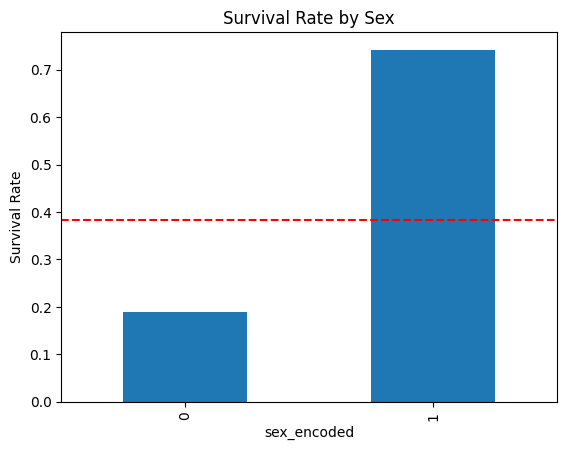

In [29]:
import matplotlib.pyplot as plt

# Overall survival rate
overall_rate = 0.384

# -------------------------------
# Pclass Plot
# -------------------------------
df_clean.groupby('Pclass')['Survived'].mean().plot(kind='bar')
plt.axhline(overall_rate, color='red', linestyle='--')
plt.title("Survival Rate by Pclass")
plt.ylabel("Survival Rate")
plt.show()

# -------------------------------
# Sex Plot
# -------------------------------
df_clean.groupby('sex_encoded')['Survived'].mean().plot(kind='bar')
plt.axhline(overall_rate, color='red', linestyle='--')
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.show()

**Step 11**

In [30]:
agg_results = df_clean.groupby('Pclass').agg({
    'Fare': 'mean',
    'Age': 'median',
    'Survived': 'mean'
}).round(3)

print("Aggregated Results by Pclass:\n")
print(agg_results)

Aggregated Results by Pclass:

         Fare    Age  Survived
Pclass                        
1       1.150  0.668     0.630
2      -0.249  0.067     0.473
3      -0.413 -0.309     0.242


In [31]:
# Class-wise average fare
df_clean['class_avg_fare'] = df_clean.groupby('Pclass')['Fare'].transform('mean')

# Difference from class average
df_clean['fare_diff'] = df_clean['Fare'] - df_clean['class_avg_fare']

print(df_clean[['Pclass', 'Fare', 'class_avg_fare', 'fare_diff']].head(10))

   Pclass      Fare  class_avg_fare  fare_diff
0       3 -0.564109        -0.41292  -0.151189
1       1  0.942548         1.15034  -0.207792
2       3 -0.548227        -0.41292  -0.135306
3       1  0.514708         1.15034  -0.635631
4       3 -0.545285        -0.41292  -0.132365
5       3 -0.535678        -0.41292  -0.122758
6       1  0.485591         1.15034  -0.664749
7       3 -0.238817        -0.41292   0.174104
8       3 -0.472738        -0.41292  -0.059817
9       2 -0.027152        -0.24853   0.221378


**Step 12**

In [32]:
pivot_table = pd.pivot_table(
    df_clean,
    values='Survived',
    index='Pclass',
    columns='sex_encoded',
    aggfunc='mean'
).round(3)

print("Pivot Table (Survival Rate):\n")
print(pivot_table)

Pivot Table (Survival Rate):

sex_encoded      0      1
Pclass                   
1            0.369  0.968
2            0.157  0.921
3            0.135  0.500


**Step 13**

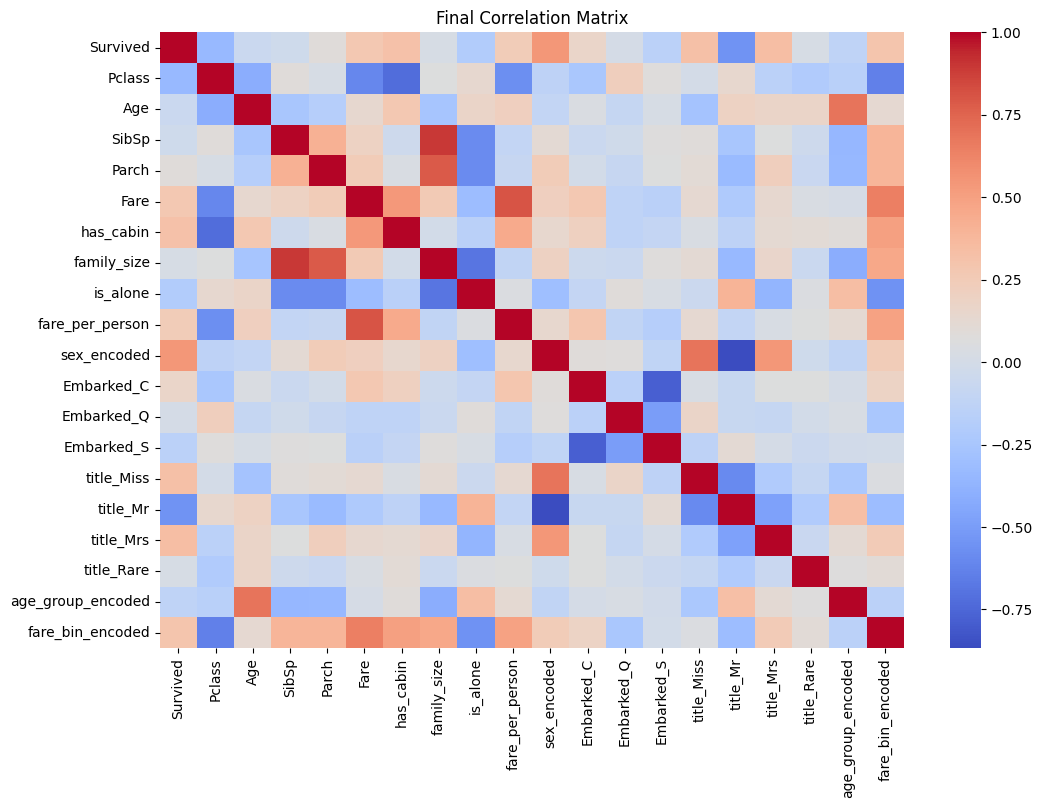

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(final_df.corr(), cmap='coolwarm', annot=False)
plt.title("Final Correlation Matrix")
plt.show()

**Step 14**

In [34]:
import numpy as np

# Select important numeric columns
cols = ['Age', 'Fare', 'fare_per_person', 'family_size', 'Survived']

np_data = final_df[cols].values

print("NumPy Array Shape:", np_data.shape)
print("\nFirst 5 rows:\n", np_data[:5])

NumPy Array Shape: (891, 5)

First 5 rows:
 [[-0.53489116 -0.56410879 -0.54760585  0.05915988  0.        ]
 [ 0.66839176  0.94254805  0.58089795  0.05915988  1.        ]
 [-0.23407043 -0.54822653 -0.39604201 -0.56097483  1.        ]
 [ 0.44277621  0.51470827  0.26044089  0.05915988  1.        ]
 [ 0.44277621 -0.54528537 -0.39163609 -0.56097483  0.        ]]


In [35]:
mean_vals = np.mean(np_data, axis=0)
std_vals = np.std(np_data, axis=0)

print("\nMean Values:", mean_vals)
print("Std Values:", std_vals)


Mean Values: [ 2.15315981e-16 -5.58226616e-17  1.99366649e-17 -2.39239978e-17
  3.83838384e-01]
Std Values: [1.         1.         1.         1.         0.48631932]


In [36]:
fare_index = cols.index('Fare')

top5_fares = np.sort(np_data[:, fare_index])[-5:]

print("\nTop 5 Highest Fares:", top5_fares)


Top 5 Highest Fares: [5.12423873 5.12423873 5.12423873 5.12423873 5.12423873]


In [37]:
mask = (final_df['sex_encoded'] == 1) & (final_df['Pclass'] == 1)

high_survival_group = final_df[mask]

print("\nHigh Survival Group Size:", high_survival_group.shape[0])
print("Survival Rate:", high_survival_group['Survived'].mean())


High Survival Group Size: 94
Survival Rate: 0.9680851063829787


In [38]:
# Correlation between Age and Fare
age_idx = cols.index('Age')
fare_idx = cols.index('Fare')

corr = np.corrcoef(np_data[:, age_idx], np_data[:, fare_idx])

print("\nCorrelation (Age vs Fare):")
print(corr)


Correlation (Age vs Fare):
[[1.         0.13375168]
 [0.13375168 1.        ]]


**Step 15**

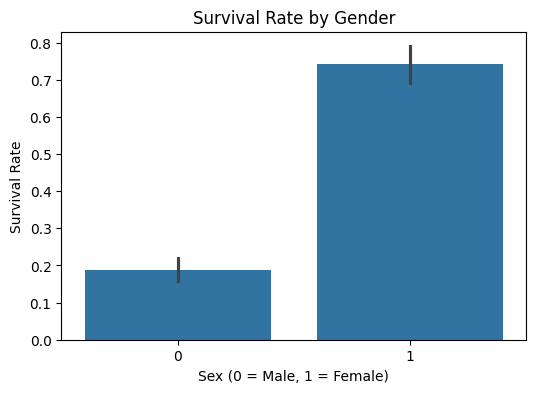

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(x='sex_encoded', y='Survived', data=df_clean)
plt.title("Survival Rate by Gender")
plt.xlabel("Sex (0 = Male, 1 = Female)")
plt.ylabel("Survival Rate")
plt.show()

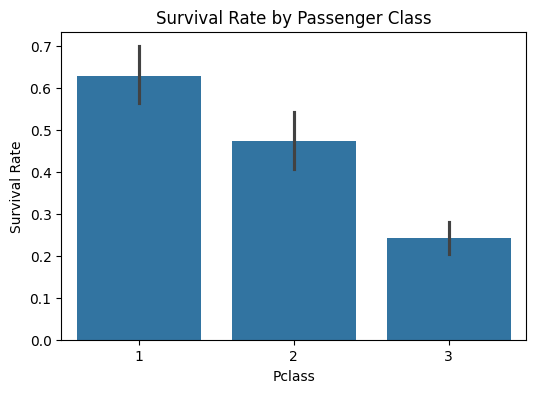

In [40]:
plt.figure(figsize=(6,4))
sns.barplot(x='Pclass', y='Survived', data=df_clean)
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

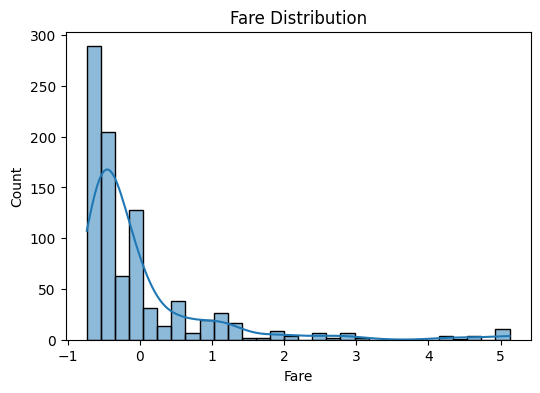

In [41]:
plt.figure(figsize=(6,4))
sns.histplot(df_clean['Fare'], bins=30, kde=True)
plt.title("Fare Distribution")
plt.show()

**Step 16**